In [3]:
import numpy as np
import pandas as pd


In [13]:
df = pd.read_csv('spam.csv')

In [16]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
710,ham,Height of Confidence: All the Aeronautics prof...,"this wont even start........ Datz confidence..""",NaN,NaN
5307,ham,What you did in leave.,NaN,NaN,NaN
2539,ham,Hmmm:)how many players selected?,NaN,NaN,NaN
4695,ham,A guy who gets used but is too dumb to realize...,NaN,NaN,NaN
83,ham,You will be in the place of that man,NaN,NaN,NaN


In [19]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [21]:
print("Shape of dataset:", df.shape)

Shape of dataset: (5572, 5)


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [25]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [26]:
df.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


## 1. Data Cleaning

In [31]:

df.head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [32]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 403


In [34]:
df = df.drop_duplicates(keep='first')

print("After removing duplicates:", df.shape)

After removing duplicates: (5169, 2)


In [35]:
print(df['label'].value_counts())
print()
print("Spam percentage:", round(df['label'].value_counts()['spam'] / len(df) * 100, 2), "%")
print("Ham percentage:", round(df['label'].value_counts()['ham'] / len(df) * 100, 2), "%")

label
ham     4516
spam     653
Name: count, dtype: int64

Spam percentage: 12.63 %
Ham percentage: 87.37 %


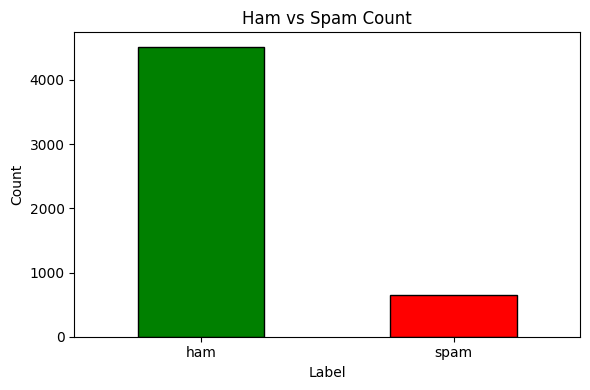

In [36]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(
    kind='bar',
    color=['green', 'red'],
    edgecolor='black',
    figsize=(6,4)
)

plt.title('Ham vs Spam Count')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [37]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['label'])  # ham -> 0, spam -> 1
df.head()

,label,message,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [41]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

df['num_characters'] = df['message'].apply(len)
df['num_words'] = df['message'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

df[['num_characters', 'num_words', 'num_sentences']].describe()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\basam\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\basam\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [42]:
df[df['label'] == 'ham'][['num_characters', 'num_words', 'num_sentences']].describe()
df[df['label'] == 'spam'][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


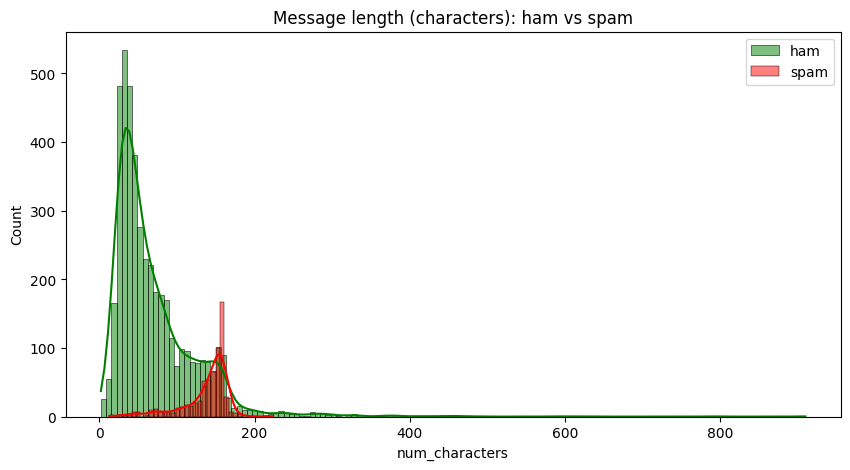

In [43]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df[df['label'] == 'ham']['num_characters'], color='green', label='ham', kde=True)
sns.histplot(df[df['label'] == 'spam']['num_characters'], color='red', label='spam', kde=True)
plt.legend()
plt.title('Message length (characters): ham vs spam')
plt.show()

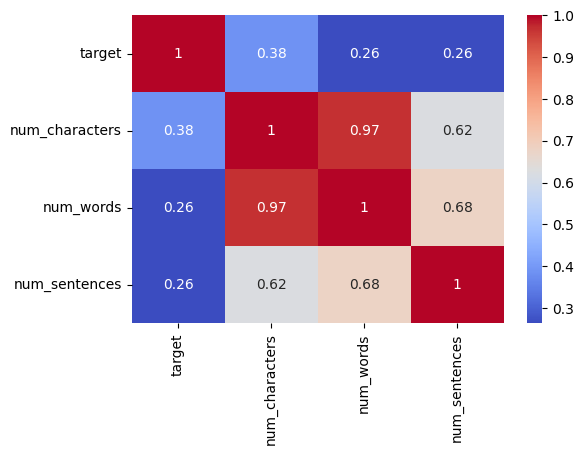

In [44]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['target', 'num_characters', 'num_words', 'num_sentences']].corr(), annot=True, cmap='coolwarm')
plt.show()

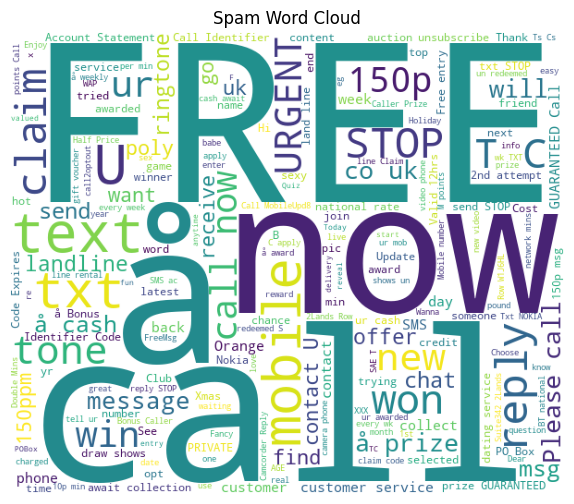

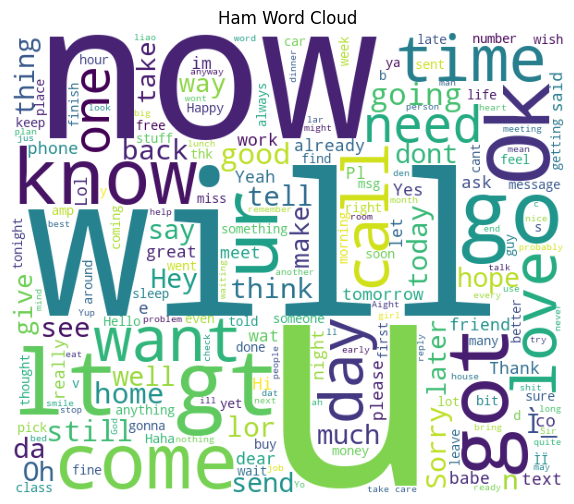

In [46]:
from wordcloud import WordCloud

wc = WordCloud(width=600, height=500, background_color='white')

plt.figure(figsize=(8, 6))
plt.imshow(wc.generate(df[df['label'] == 'spam']['message'].str.cat(sep=' ')))
plt.axis('off')
plt.title('Spam Word Cloud')
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(wc.generate(df[df['label'] == 'ham']['message'].str.cat(sep=' ')))
plt.axis('off')
plt.title('Ham Word Cloud')
plt.show()

In [47]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download('stopwords')

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\basam\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [48]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    # keep only alphanumeric tokens (drops punctuation, emojis, symbols)
    text = [word for word in text if word.isalnum()]

    # remove stopwords ("the", "is", "at"...) and stray punctuation
    text = [word for word in text if word not in stop_words and word not in string.punctuation]

    # stem to root form: "winning" -> "win", "loved" -> "love"
    text = [ps.stem(word) for word in text]

    return " ".join(text)

In [49]:
print(df['message'][0])
print(transform_text(df['message'][0]))

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
go jurong point crazi avail bugi n great world la e buffet cine got amor wat


In [50]:
df['transformed_message'] = df['message'].apply(transform_text)
df.head()

,label,message,target,num_characters,num_words,num_sentences,transformed_message
0,ham,"Go until jurong point, crazy.. Available only ...",0,111,24,2,go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,0,29,8,2,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,0,49,13,1,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",0,61,15,1,nah think goe usf live around though


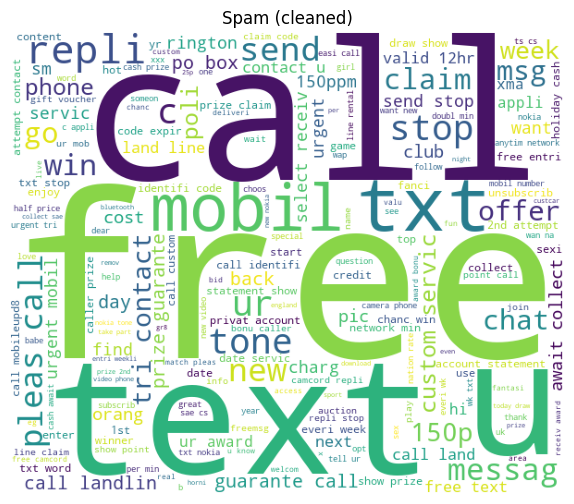

In [51]:
wc = WordCloud(width=600, height=500, background_color='white')

spam_wc = wc.generate(df[df['label'] == 'spam']['transformed_message'].str.cat(sep=' '))
plt.figure(figsize=(8,6)); plt.imshow(spam_wc); plt.axis('off'); plt.title('Spam (cleaned)'); plt.show()

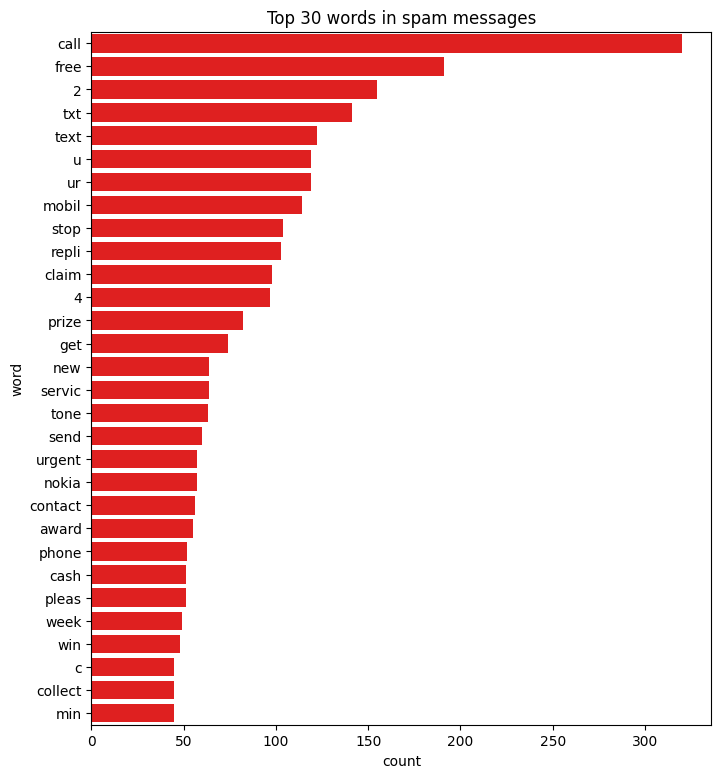

In [52]:
from collections import Counter

spam_words = []
for msg in df[df['label'] == 'spam']['transformed_message']:
    spam_words.extend(msg.split())

top_30 = pd.DataFrame(Counter(spam_words).most_common(30), columns=['word', 'count'])

plt.figure(figsize=(8, 9))
sns.barplot(x='count', y='word', data=top_30, color='red')
plt.title('Top 30 words in spam messages')
plt.show()

In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_message']).toarray()
y = df['target'].values  # from LabelEncoder earlier: ham=0, spam=1

print(X.shape, y.shape)

(5169, 3000) (5169,)


In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2, stratify=y
) 


In [55]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

models = {
    "Gaussian NB": GaussianNB(),
    "Multinomial NB": MultinomialNB(),
    "Bernoulli NB": BernoulliNB(),
    "Logistic Regression": LogisticRegression(solver='liblinear'),
    "SVM": SVC(kernel='sigmoid', gamma=1.0, probability=True),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=2),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=2),
    "Extra Trees": ExtraTreesClassifier(n_estimators=50, random_state=2),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=2),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    results.append({"Model": name, "Accuracy": acc, "Precision": prec})
    print(f"{name:<20} Accuracy: {acc:.4f}   Precision: {prec:.4f}")

Gaussian NB          Accuracy: 0.8762   Precision: 0.5064
Multinomial NB       Accuracy: 0.9826   Precision: 1.0000
Bernoulli NB         Accuracy: 0.9874   Precision: 0.9758
Logistic Regression  Accuracy: 0.9623   Precision: 0.9792
SVM                  Accuracy: 0.9855   Precision: 0.9677
Decision Tree        Accuracy: 0.9313   Precision: 0.7727
KNN                  Accuracy: 0.9149   Precision: 1.0000
Random Forest        Accuracy: 0.9845   Precision: 1.0000
AdaBoost             Accuracy: 0.9159   Precision: 0.7292
Extra Trees          Accuracy: 0.9836   Precision: 0.9750
Gradient Boosting    Accuracy: 0.9603   Precision: 0.9688


In [56]:
results_df = pd.DataFrame(results).sort_values(by=['Precision', 'Accuracy'], ascending=False)
results_df

,Model,Accuracy,Precision
7,Random Forest,0.984526,1.000000
1,Multinomial NB,0.982592,1.000000
6,KNN,0.914894,1.000000
3,Logistic Regression,0.962282,0.979167
2,Bernoulli NB,0.987427,0.975806
9,Extra Trees,0.983559,0.975000
10,Gradient Boosting,0.960348,0.968750
4,SVM,0.985493,0.967742
5,Decision Tree,0.931335,0.772727
8,AdaBoost,0.915861,0.729167


In [57]:
for max_feat in [1000, 2000, 3000, 4000, 5000, None]:
    tfidf_test = TfidfVectorizer(max_features=max_feat)
    X_test_feat = tfidf_test.fit_transform(df['transformed_message']).toarray()
    X_tr, X_te, y_tr, y_te = train_test_split(X_test_feat, y, test_size=0.2, random_state=2, stratify=y)

    mnb = MultinomialNB()
    mnb.fit(X_tr, y_tr)
    pred = mnb.predict(X_te)

    label = max_feat if max_feat else "all"
    print(f"max_features={label}   Accuracy: {accuracy_score(y_te, pred):.4f}   Precision: {precision_score(y_te, pred):.4f}")

max_features=1000   Accuracy: 0.9845   Precision: 0.9832
max_features=2000   Accuracy: 0.9816   Precision: 1.0000
max_features=3000   Accuracy: 0.9826   Precision: 1.0000
max_features=4000   Accuracy: 0.9778   Precision: 1.0000
max_features=5000   Accuracy: 0.9768   Precision: 1.0000
max_features=all   Accuracy: 0.9671   Precision: 1.0000


In [58]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_chars_scaled = scaler.fit_transform(df[['num_characters']])

X_combined = np.hstack((X, num_chars_scaled))  # X is your original TF-IDF(3000) matrix

X_tr, X_te, y_tr, y_te = train_test_split(X_combined, y, test_size=0.2, random_state=2, stratify=y)
mnb = MultinomialNB()
mnb.fit(X_tr, y_tr)
pred = mnb.predict(X_te)
print("With length feature ->", "Accuracy:", accuracy_score(y_te, pred), "Precision:", precision_score(y_te, pred))

With length feature -> Accuracy: 0.9816247582205029 Precision: 1.0


In [59]:
from sklearn.ensemble import VotingClassifier

svm = SVC(kernel='sigmoid', gamma=1.0, probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

voting = VotingClassifier(estimators=[('svm', svm), ('mnb', mnb), ('etc', etc)], voting='soft')
voting.fit(X_train, y_train)
pred = voting.predict(X_test)
print("Voting Ensemble -> Accuracy:", accuracy_score(y_test, pred), "Precision:", precision_score(y_test, pred))

Voting Ensemble -> Accuracy: 0.9912959381044487 Precision: 0.9919354838709677


In [60]:
import pickle

final_tfidf = TfidfVectorizer(max_features=3000)
X_final = final_tfidf.fit_transform(df['transformed_message'])

final_model = MultinomialNB()
final_model.fit(X_final, y)  # trained on ALL the data now

pickle.dump(final_tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(final_model, open('model.pkl', 'wb'))

In [61]:
# Load the saved files back
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer

loaded_vectorizer = pickle.load(open('vectorizer.pkl', 'rb'))
loaded_model = pickle.load(open('model.pkl', 'rb'))

print("✓ Both files loaded successfully!")
print()

# Test with a spam message
spam_test = "Congratulations! You won a free iPhone. Click here to claim your prize now! Call 88888"
transformed_spam = transform_text(spam_test)
vectorized_spam = loaded_vectorizer.transform([transformed_spam])
result_spam = loaded_model.predict(vectorized_spam)
print("Test 1 (should be SPAM):", spam_test[:50], "...")
print("Result:", "✓ SPAM" if result_spam[0] == 1 else "✗ HAM")
print()

# Test with a ham message
ham_test = "Hey, are we still meeting for lunch tomorrow at 1pm?"
transformed_ham = transform_text(ham_test)
vectorized_ham = loaded_vectorizer.transform([transformed_ham])
result_ham = loaded_model.predict(vectorized_ham)
print("Test 2 (should be HAM):", ham_test)
print("Result:", "✓ HAM" if result_ham[0] == 0 else "✗ SPAM")

✓ Both files loaded successfully!

Test 1 (should be SPAM): Congratulations! You won a free iPhone. Click here ...
Result: ✓ SPAM

Test 2 (should be HAM): Hey, are we still meeting for lunch tomorrow at 1pm?
Result: ✓ HAM


In [63]:
import os

print("Your .pkl files are saved here:")
print(os.getcwd())
print()
print("Files found:")
for f in os.listdir():
    if f.endswith('.pkl'):
        size = os.path.getsize(f)
        print(f"  ✓ {f}  ({size} bytes)")

Your .pkl files are saved here:
C:\Users\basam\Machine Learning Folder

Files found:
  ✓ model.pkl  (96608 bytes)
  ✓ vectorizer.pkl  (105703 bytes)
